[[ 54.7141057   17.78318133  -3.04245896]
 [-47.9043208   23.59671232 -45.71401284]
 [ 76.49443357 -33.01975234 -49.39780435]
 [-72.53364916  39.03633995  36.3134845 ]
 [ -6.67579192  -0.58604716 -83.18974617]
 [ 72.2190822  -98.28185946 -93.43266295]
 [-57.26122305  81.09373101 -32.89997058]
 [-68.60526525  57.09085387  67.12074541]
 [ 56.28015715  23.15611248  -6.96803169]
 [ 69.47634743  50.34119636  74.29778669]
 [-91.88342195  84.82609808  -9.43333167]
 [  4.60061366  -4.30319773 -87.55340222]
 [-97.74162697 -57.78668115 -56.95038719]
 [ 82.54644563 -52.47183148 -78.77706442]
 [-73.97802991 -28.04812399  -9.57590193]
 [ -2.82634836 -40.71455293 -10.86353353]
 [ 50.04831105 -17.53770062 -26.14979202]
 [-54.9863101   74.83879955  61.23372295]
 [ 81.7628115   28.39634785 -42.82026337]
 [ 27.27470774  65.62668858  69.39718398]
 [ 23.81862407 -86.51133206  62.2303733 ]
 [ 15.75932502 -21.09013507  44.77931509]
 [ 24.12434295  36.99947718  -5.01341387]
 [ 95.18069987 -83.74265205  91.98

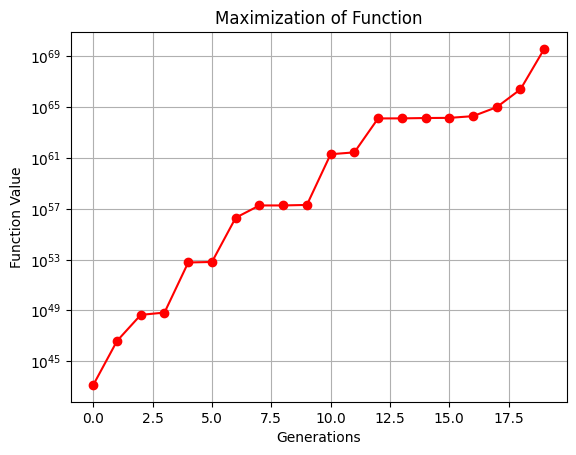

In [1]:
# low = lower range for variables, high = higher range for variables
import math
def genesis(size,var, high , low):
    pop_size = (size,var)
    new_pop = np.random.uniform(low=low,high=high,size=pop_size)
    return new_pop



def fitness(p):
# Evaluating fitness Interference function "double fit (doublep[])".
    fitness=np.zeros((len(p),1))
    for i in range(len(p)):
        x,y,z = p[i][0] , p[i][1] , p[i][2]
            # Define your fitness function here
        fitness[i,0] = 2*x*z*math.e**(-x)-2*y**3+y**2-3*z**3
    return fitness



def selection(pop, fitness, num_parents):
    parents = np.empty((num_parents, pop.shape[1]))
    for parent_num in range(num_parents):
        max_fitness_idx = np.where(fitness == np.max(fitness))
        max_fitness_idx = max_fitness_idx[0][0]
        parents[parent_num, :] = pop[max_fitness_idx, :]
        fitness[max_fitness_idx] = -99999999999
    return parents


def crossover(parents, offspring_size):
    offspring = np.empty(offspring_size)
    crossover_point = np.uint8(offspring_size[1]/2)
    for k in range(offspring_size[0]):
        parent1_idx = k%parents.shape[0]
        parent2_idx = (k+1)%parents.shape[0]
        offspring[k, 0:crossover_point] = parents[parent1_idx,     0:crossover_point]
        offspring[k, crossover_point:] = parents[parent2_idx, crossover_point:]
    return offspring



def mutation(offspring_crossover):
    for idx in range(offspring_crossover.shape[0]):
        random_value = np.random.uniform(-10, 10, 1)
    # 10 percent change maximum keeping 90 percent mutation rate
        i= randint(0, 2)
        offspring_crossover[idx, i] = offspring_crossover[idx, i] + random_value
    return offspring_crossover


import numpy as np
from random import randint

num_var = 3
sizeof_pop= 100
upper_limit = 100
lower_limit = -100
num_parents = 2
population = genesis(sizeof_pop , num_var, upper_limit ,lower_limit)
print(population)
Scores=[]
num_generations = 20



for generation in range(num_generations):
    print("\n\nGeneration : ", generation)
    fitness_score = fitness(population)
    parents = selection(population, fitness_score, num_parents)
    print("Best Parents \n",parents)
    offspring_crossover = crossover(parents, offspring_size=(2*num_parents, num_var))
    offspring_mutation = mutation(offspring_crossover)
    print("Mutated OffSprings\n",offspring_mutation)
    population[0:parents.shape[0], :] = parents
    population[parents.shape[0]:6, :] = offspring_mutation
    Scores.append(np.max(fitness_score))
    print("Best result : ", np.max(fitness_score))


import matplotlib.pyplot as plt
Evaluations = Scores
plt.plot(Evaluations,'o-',color='red')
plt.yscale('log')
plt.xlabel('Generations')
plt.ylabel('Function Value')
plt.title("Maximization of Function")
plt.grid(True)
plt.show()